> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 4: Data Understanding

## Outline

- Load and preview a real-world dataset
- Inspect structure and identify data quality issues, such as missing or unusual data
- Perform basic grouped summaries to see trends

We are focused on the data understanding phase in business analytics.  The tasks in this labe will help you figure out what the data actually contains before you start making decisions or building models. By exploring the dataset, you can identify key details such as the meaning of each column, the types of data (numeric, categorical, etc.), the presence of missing or inconsistent values, and the overall size and structure of the data. It’s also important to look for patterns, unusual values, or outliers that could affect your analysis. Taking the time to understand your data early helps prevent mistakes, ensures your analysis is accurate, and guides you toward asking the right questions.


<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_04_data_understanding.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     |  Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1). |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

### Note on importing data:
- In this lab we will be importing data from a website, rather than a Python library
- A "CSV" file is a text file that has commma separated values.  You can open the file in Excel, Pandas, or in a notepad on your laptop.
- GitHub can host text files as well as code.  In this case we are pulling the data directly from GitHub into a dataframe.

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

df.info()

/tmp/ipykernel_2380/2808982895.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [3]:
df.head(15)

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN
5,pre2013_152345,20060411,2006.0,alameda,alameda,alameda,825.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,$825 / 1br - Bayview Apartments,NaN,NaN
6,pre2013_27543,20071025,2007.0,alameda,alameda,alameda,1500.0,1.0,1.0,NaN,0.0,NaN,NaN,NaN,$1500 / 1br - 1 Bath-3 Room Apartment - OPEN S...,NaN,NaN
7,6379096957,20171108,2017.0,alameda,alameda,alameda,2925.0,3.0,NaN,NaN,0.0,NaN,NaN,NaN,CUT DOWN ON THOSE MOVE-IN COSTS WITH $500 OFF!!!,NaN,NaN
8,pre2013_6254,20090205,2009.0,alameda,alameda,alameda,450.0,NaN,1.0,NaN,0.0,NaN,NaN,NaN,"$450 Sleeping room, all utilities included, sh...",NaN,NaN
9,pre2013_152262,20060411,2006.0,alameda,alameda,alameda,1395.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,"$1395 / 2br - Huge Units! Lagoon Complex, Free...",NaN,NaN


### 🔧 Do the following – Part 1

1. Add one line of code to print the number of rows and columns.

In [5]:
print(df.shape)

(200810, 17)


## 2. Inspecting the Data

### Instructions:
- Identify missing values.
- Check data types are correct(e.g., dates, numeric columns).
- Check for outliers key numeric variables like `price`, `sqft`, `beds`, or `baths`. The concept of outliers will be covered more in week 6.  This week we will do only a very basic filter for outlier values.   

### Think about:
- Are there missing values?
- Do the data types look appropriate?

In [6]:
# Check for missing values
df.isnull().sum()

,0
post_id,0
date,13
year,14
nhood,14
city,14
county,1408
price,14
beds,6622
baths,158135
sqft,136131


In [7]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


In [8]:
# Check data types
df.dtypes

,0
post_id,object
date,object
year,float64
nhood,object
city,object
county,object
price,float64
beds,float64
baths,float64
sqft,float64


### 🔧 Do the following – Part 2

1. Use `.describe()` to inspect the **square footage (`sqft`)** by itself.

In [10]:
df['sqft'].describe()

,sqft
count,64679.000000
mean,1201.827688
std,5000.217864
min,80.000000
25%,750.000000
50%,1000.000000
75%,1360.000000
max,900000.000000


### Reflection:
2.1. What patterns or issues do you see with square footage values? Is there anything unusual?


### ✍️ Your Response: 🔧
2.1. There is a minimum square footage value of 80, which is way too small for any realistic rental. There is also a max of 900,000 square feet which is also highly unrealstic.

## 3. Basic Exploration

Use `groupby` and `value_counts` to summarize trends across neighborhoods and cities.  The concept of data exploration will be covered more in week 5.


In [12]:
# Average price by neighborhood
df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

,price
nhood,
inverness,5310.000000
atherton,4536.010989
tiburon / belvedere,4265.346591
financial district,3958.161417
west portal / forest hills,3827.276119
saratoga,3801.850900
kentfield / ross,3611.577855
los altos,3605.047072
SOMA / south beach,3585.900793


In [11]:
# Top cities by count
df['city'].value_counts().head(10)

,count
city,
san francisco,55730
san jose,13733
oakland,9443
santa rosa,6230
santa cruz,5464
san mateo,5127
sunnyvale,4526
mountain view,4414
berkeley,4201


### 🔧 Do the following – Part 3

Seek to understand the data by performing the following:

1. Group the listings by `year` and calculate the average price for each year.  Sort the results by year.
2. Create a line chart to show the average price by year (from step 1)
2. Use `.value_counts()` on the `room_in_apt` column to see how common room rentals are.

Average Price by Year:
year
2000.0    1418.695652
2001.0    2070.038095
2002.0    1709.347079
2003.0    1587.705745
2004.0    1640.209812
2005.0    1525.475233
2006.0    1822.992589
2007.0    2152.303178
2008.0    2067.772489
2009.0    1951.866827
2010.0    1831.296377
2011.0    2082.872963
2012.0    2126.308527
2013.0    2679.816015
2014.0    2799.560424
2015.0    3016.057967
2016.0    2892.953247
2017.0    2998.658354
2018.0    2967.051076
Name: price, dtype: float64


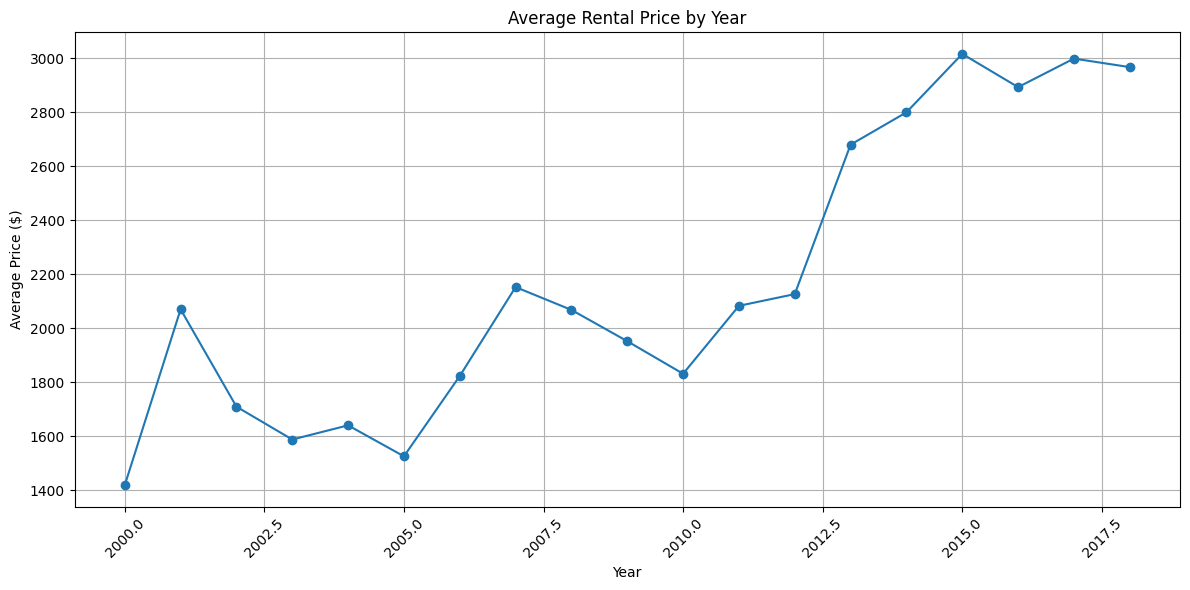


Room in Apartment (1) vs. Full Apartment (0) counts:
room_in_apt
0.0    200511
1.0       285
Name: count, dtype: int64


In [15]:
import matplotlib.pyplot as plt

# Group by year and calculate average price, sorted by year
avg_price_by_year = df.groupby('year')['price'].mean().sort_index(ascending=True)
print("Average Price by Year:")
print(avg_price_by_year)

# Create a line chart to show the average price by year
plt.figure(figsize=(12, 6))
avg_price_by_year.plot(kind='line', marker='o')
plt.title('Average Rental Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Use value_counts on room_in_apt to see how common room rentals are
print("\nRoom in Apartment (1) vs. Full Apartment (0) counts:")
print(df['room_in_apt'].value_counts())


## 4. Reflection:

4.1. Explain, in detail, any trends you see with year and room_in_apt.

4.2. What would be the right way to handle missing data in several of the variables?  Are those variables usable and useful?

### ✍️ Your Response: 🔧
4.1. The trends I see with year is that it generally increases as the years go by. Prices rose sharply after 2012. Most data values are from renting a room in an apartment, rather than the full apartment itself.

4.2. The right way to handle missing data in several of the variables is to handle it by the type. If it's a numerical variable, you could fill in values using the median, while categorical values could use an "unkown" column. The variables may still be useful, but conclusions should be intepreted with caution because the data could create bias.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [16]:
!jupyter nbconvert --to html "lab_04_data_understanding.ipynb"

[NbConvertApp] Converting notebook lab_04_data_understanding.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 399150 bytes to lab_04_data_understanding.html
